In [1]:
from matplotlib import pyplot as plt
import numpy as np
import sys
import pandas as pd
sys.path.insert(1, '/home/adriano/projects/alphag_frequentist_analysis_2025/v1')

from Utils import ReadTheCsv,ReadTheSpill,append_to_dict

In [2]:
!ls
!pwd

Counts.ipynb	      bias_dictionary.json    residuals_L_2.png
D_extraction.ipynb    config.txt	      residuals_L_3.png
DetectorStudies       microwave_mirrorA.png   residuals_L_6.png
Normalization	      microwave_mirrorG.png   scurve_L_0.66.png
Run-MonteCarlo.ipynb  readme.txt	      scurve_L_1.png
Simulation-v2.ipynb   residuals_D_L_0.66.png  scurve_L_2.png
TomAgMacros.C	      residuals_D_L_1.png     scurve_L_3.png
Zpdf_comparison.png   residuals_D_L_2.png     scurve_L_6.png
__pycache__	      residuals_D_L_3.png     simulation.csv
ag14259		      residuals_D_L_6.png     utils.py
ag14260		      residuals_L_0.66.png
analysis_output       residuals_L_1.png
/home/adriano/projects/alphag_frequentist_analysis_2025/DetectorAsymmetry


In [3]:
# Coordinate System
#- - - - - - - - - - - 
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"
# - - - - - - - - - - -

class Zcuts:
    def __init__(self,a,b):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a

ZCUTS = Zcuts(-415,-671)

bkg_up   = 0.0010
bkg_down = 0.0009

def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):
    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zmin) & (data["Z"] < zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zgap_max) & (data["Z"] < zmax)
    return Nup.sum() - bkg_up*(stop - start), Ndwn.sum() - bkg_down*(stop - start)

In [4]:
runs = {"Mirror A"              : "DetectorStudies/ag14245.vertex.csv",
       "Miror G normalization"  : "DetectorStudies/ag14246.vertex.csv",
       "Mirror G"               : "DetectorStudies/ag14247.vertex.csv"}

# runs = {"Mirror A"              : "DetectorStudies/ag14259.vertex.csv",
#        "Miror G normalization"  : "DetectorStudies/ag14260.vertex.csv",
#        "Mirror G"               : "DetectorStudies/ag14260.vertex.csv"}

dataset_mirrA = ReadTheCsv(runs["Mirror A"], "-1", ZCUTS.zmin, ZCUTS.zmax, CutsType)
dataset_mirrG = ReadTheCsv(runs["Mirror G"], "-1", ZCUTS.zmin, ZCUTS.zmax, CutsType)
dataset_norm  = ReadTheCsv(runs["Miror G normalization"], "-1", zmin, zmax, CutsType)

cb_kickout  = []
mirros_ramps = []
Asymmetry = [-1, +1]

# Microwave Knife distribution, MIRROR A RELEASE

DetectorStudies/ag14245.vertex.csv
   [4451.187-5987.214]=1536.027s |          "Microwave Dump"[0]         |  169991     8336     8296     5570    82784    62570   191332   116215   320160       463 

DetectorStudies/ag14245.vertex.csv
   [6033.167-6354.371]= 321.205s |          "MAG rampdown"[0]           |   34425     1724     1696     1176    17401    13072    40581    24750    67626       236 

DetectorStudies/ag14245.vertex.csv
   [6457.504-6563.607]= 106.103s |          "Oc RampDown"[0]            |   11274      576      578      388     5657     4469    13433     8040    22370        18 

-0.15 94.865


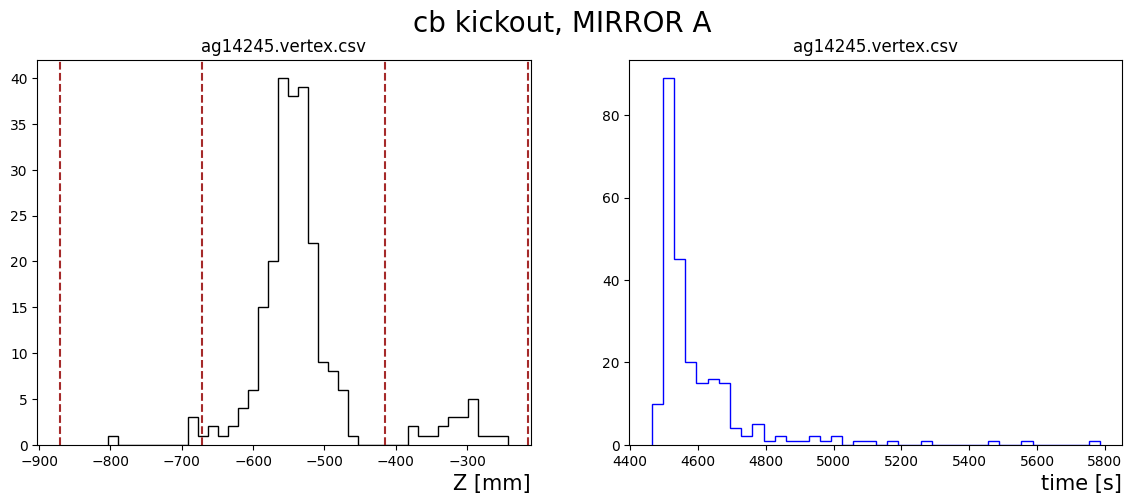

In [5]:
plt.figure(1, figsize = (14,5))
plt.suptitle("cb kickout, MIRROR A", fontsize = 20)
plt.subplot(1,2,1)

# Extract the mw dump markers
mw_cb_start, mw_cb_stop = ReadTheSpill(runs["Mirror A"], "\"Microwave Dump\"[0]") # Microwave DUMP
mask =  (dataset_mirrA["run time"] > mw_cb_start[0]) & (dataset_mirrA["run time"] < mw_cb_stop[0])

# Plot c state kickout
plt.title(f"{runs['Mirror A'].replace('DetectorStudies/', '')}") # title
plt.hist(dataset_mirrA["Z"][mask], color = "black", bins = 40, histtype = 'step')
plt.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
plt.axvline(zmax,linestyle = "--", color = "brown")
plt.axvline(zgap_min,linestyle = "--", color = "brown")
plt.axvline(zgap_max,linestyle = "--", color = "brown")
plt.xlabel("Z [mm]", fontsize = 15, loc = "right")
plt.subplot(1,2,2)
plt.title(f"{runs['Mirror A'].replace('DetectorStudies/', '')}") # title
plt.xlabel("time [s]", fontsize = 15, loc = "right")
plt.hist(dataset_mirrA["run time"][mask], color = "blue", bins = 40, histtype = 'step')

plt.savefig("microwave_mirrorA.png", bbox_inches = "tight")

cb_kickout.append(mask.sum()) # append to normalization array


# Extract the Z counts
mirror_start, mirror_stop = ReadTheSpill(runs["Mirror A"], "\"MAG rampdown\"[0]") # mirror dump
oct_start, oct_stop = ReadTheSpill(runs["Mirror A"], "\"Oc RampDown\"[0]") # mirror dump

# time is selected from Oc rampdown
start = oct_start[0] - 150
stop = oct_start[0]
Nup, Ndown = NupNdown(dataset_mirrA, start , stop , ZCUTS.zmin, ZCUTS.zmax, ZCUTS.zgap_min, ZCUTS.zgap_max)
print(Nup, Ndown)
mirros_ramps.append(Ndown)

## Z vs. Time Distributions

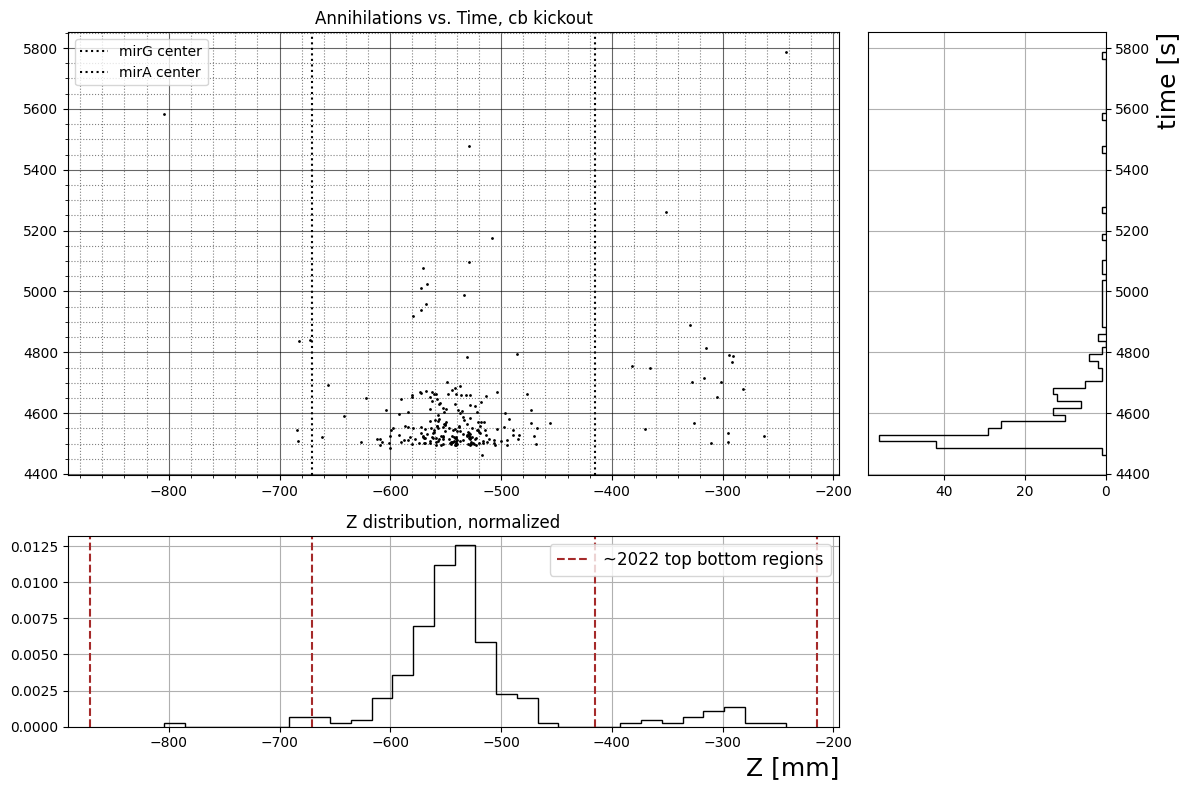

In [6]:
def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):
    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > ZCUTS.zmin) & (data["Z"] < ZCUTS.zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > ZCUTS.zgap_max) & (data["Z"] < ZCUTS.zmax)
    return Nup.sum(), Ndwn.sum()

mask   = (dataset_mirrA["run time"] > mw_cb_start[0]) & (dataset_mirrA["run time"] < mw_cb_stop[0])

Nup, Ndown = NupNdown(dataset_mirrA, mw_cb_start[0], mw_cb_stop[0], ZCUTS.zmin, ZCUTS.zmax, ZCUTS.zgap_min, ZCUTS.zgap_max)

Nup   -= bkg_up   * (mw_cb_start[0] - mw_cb_stop[0])
Ndown -= bkg_down * (mw_cb_start[0] - mw_cb_stop[0])

#S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.errorbar(dataset_mirrA["Z"][mask], dataset_mirrA["run time"][mask] , color = "black", marker = ".", linestyle = "", markersize = 2)
ax1.axvline(mirG_center, linestyle = "dotted", color = "black", label = "mirG center")
ax1.axvline(mirA_center, linestyle = "dotted", color = "black", label = "mirA center")

ax1.set_title("Annihilations vs. Time, cb kickout")
ax1.set_xlim(zmin-20,zmax+20)
ax1.legend()
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(dataset_mirrA["Z"][mask], bins = 30, histtype = "step", color = "black", density = True)
ax2.axvline(ZCUTS.zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(ZCUTS.zmax,linestyle = "--", color = "brown")
ax2.axvline(ZCUTS.zgap_min,linestyle = "--", color = "brown")
ax2.axvline(ZCUTS.zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)
ax2.grid()

counts, bins, _ = ax3.hist(dataset_mirrA["run time"][mask], bins = 60, histtype = "step",  color = "black", density = False,  orientation='horizontal')
xgrid = np.linspace(bins[4], bins[-1], 100)

#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()
ax3.grid()

plt.tight_layout()
plt.show()
#fig.savefig(f"MBMF_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

# Microwave Distribution, MIRROR G RELEASE

DetectorStudies/ag14246.vertex.csv
DetectorStudies/ag14247.vertex.csv
   [ 212.471- 318.574]= 106.103s |          "Oc RampDown"[0]            |   11110      597      585      366     5644     4404    13453     7802    21878        29 

103 1


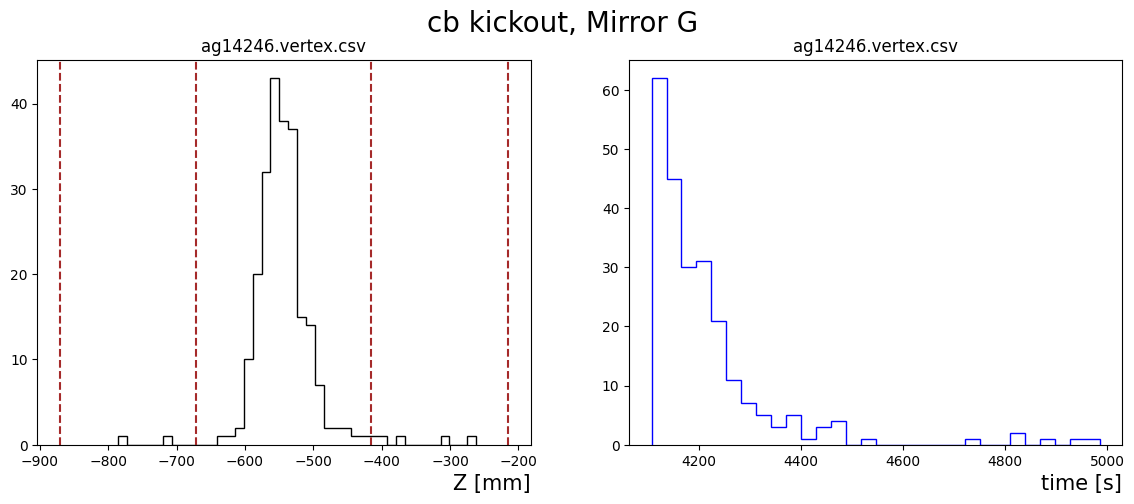

In [7]:

# Extract the mw dump markers
mw_cb_start, mw_cb_stop = ReadTheSpill(runs["Miror G normalization"], "\"Microwave Dump\"[0]") # Microwave DUMP

if not mw_cb_start: # if empty, it's run 14246 with problems with dump markers
    mask =  (dataset_norm["run time"] > 4106) & (dataset_norm["run time"] < 5000)
else:
    mask =  (dataset_norm["run time"] > mw_cb_start[0]) & (dataset_norm["run time"] < mw_cb_stop[0])
    


plt.figure(2, figsize = (14,5))
plt.suptitle("cb kickout, Mirror G", fontsize = 20)
plt.subplot(1,2,1)
plt.title(f"{runs['Miror G normalization'].replace('DetectorStudies/', '')}") # title
plt.hist(dataset_norm["Z"][mask], color = "black", bins = 40, histtype = 'step')
plt.axvline(ZCUTS.zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
plt.axvline(ZCUTS.zmax,linestyle = "--", color = "brown")
plt.axvline(ZCUTS.zgap_min,linestyle = "--", color = "brown")
plt.axvline(ZCUTS.zgap_max,linestyle = "--", color = "brown")
plt.xlabel("Z [mm]", fontsize = 15, loc = "right")
plt.subplot(1,2,2)
plt.title(f"{runs['Miror G normalization'].replace('DetectorStudies/', '')}") # title
plt.xlabel("time [s]", fontsize = 15, loc = "right")
plt.hist(dataset_norm["run time"][mask], color = "blue", bins = 30, histtype = 'step')

plt.savefig("microwave_mirrorG.png", bbox_inches = "tight")

cb_kickout.append(mask.sum())

# Extract the Z counts
oct_start, oct_stop = ReadTheSpill(runs["Mirror G"], "\"Oc RampDown\"[0]") # Oct ramp down

# time is selected from Oc rampdown
start = oct_start[0] - 150
stop = oct_start[0]

Nup, Ndown = NupNdown(dataset_mirrG, start , stop , ZCUTS.zmin, ZCUTS.zmax, ZCUTS.zgap_min, ZCUTS.zgap_max)
print(Nup, Ndown)
mirros_ramps.append(Nup)

In [8]:
print(cb_kickout)
print(mirros_ramps)

[238, 235]
[94.865, 103]


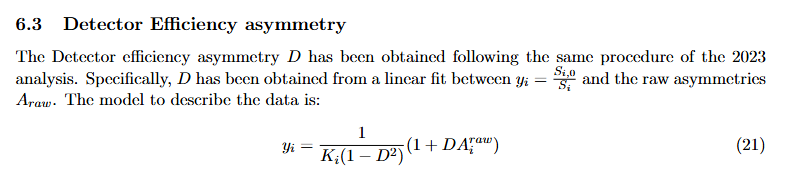
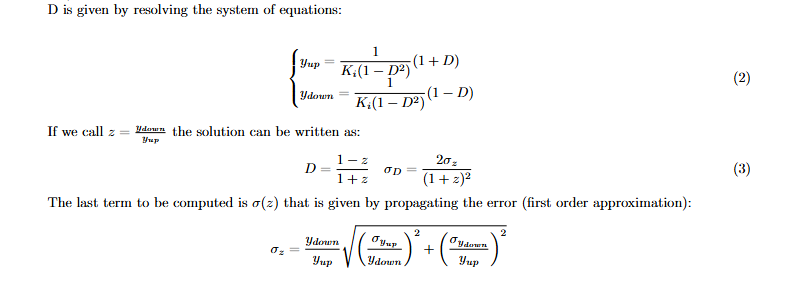

In [9]:
mirros_ramps = np.array(mirros_ramps)
cb_kickout = np.array(cb_kickout)

y = np.array(cb_kickout)/np.array(mirros_ramps)
x = np.array(Asymmetry)
print(y, x)

def ratio_with_error(A, sigma_A, B, sigma_B):
    R = A / B
    sigma_R = R * np.sqrt((sigma_A/A)**2 + (sigma_B/B)**2)
    return R, sigma_R

y, dy = ratio_with_error(cb_kickout, np.sqrt(cb_kickout), mirros_ramps , np.sqrt(mirros_ramps) )
print(y, dy)

ydown, dydown = y[0], dy[0]
yup, dyup     = y[1], dy[1]

z , dz = ratio_with_error(ydown, dydown, yup, dyup)
print(z, dz)

D = (1 - z)/(1 + z)
dD = 2 * dz/(1 + z**2)

print(f"Detector Efficiency Asymmetry, quick and dirty: {D:.3f} +/- {dD:.3f}")

[2.50882834 2.2815534 ] [-1  1]
[2.50882834 2.2815534 ] [0.30462359 0.26961028]
1.099614121298912 0.1863092700520871
Detector Efficiency Asymmetry, quick and dirty: -0.047 +/- 0.169


# Comparison Distributions Single Mirror Release vs. -2.0g 0.0g laser cooled atoms

In [10]:
#----------------------
dataset_2025_1 = ReadTheCsv("../v1/ag14100/ag14100.vertex.csv","-1", zmin, zmax, CutsType)
dataset_2025_2 = ReadTheCsv("../v1/ag14106/ag14106.vertex.csv","-1", zmin, zmax, CutsType)

dataset_2025 = pd.concat([dataset_2025_1, dataset_2025_2], axis=0)

DetectorStudies/ag14245.vertex.csv
   [6033.167-6354.371]= 321.205s |          "MAG rampdown"[0]           |   34425     1724     1696     1176    17401    13072    40581    24750    67626       236 

DetectorStudies/ag14245.vertex.csv
   [6457.504-6563.607]= 106.103s |          "Oc RampDown"[0]            |   11274      576      578      388     5657     4469    13433     8040    22370        18 

DetectorStudies/ag14247.vertex.csv
   [ 212.471- 318.574]= 106.103s |          "Oc RampDown"[0]            |   11110      597      585      366     5644     4404    13453     7802    21878        29 

../v1/ag14100/ag14100.vertex.csv
   [26640.301-26740.304]= 100.003s |          "WaitForQuasitrapped"[0]    |   10556      507      530      349     5310     3878    12216     7721    20590        38 

../v1/ag14100/ag14100.vertex.csv
   [27249.259-27849.266]= 600.008s |          "WaitForQuasitrapped"[1]    |   63267     3287     3233     2072    32031    23689    73469    45788   124065       3

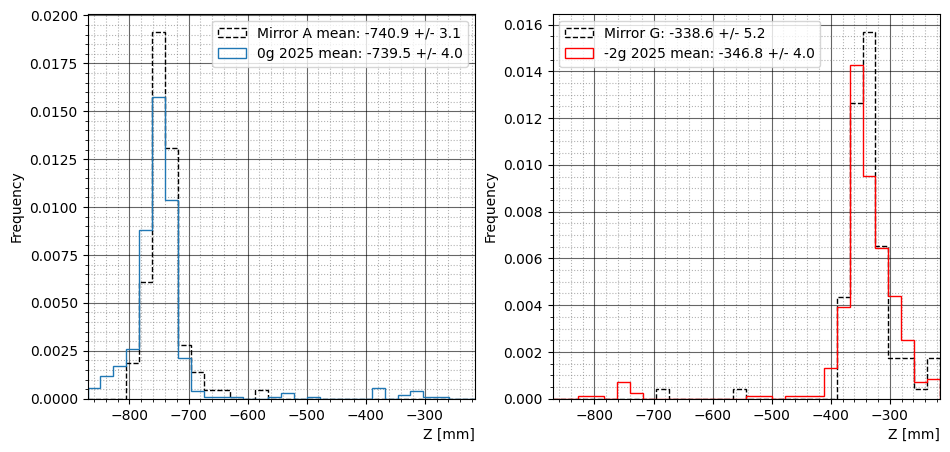

In [11]:
plt.figure(figsize = (11, 5))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

# Extract the Z counts
mirror_start, mirror_stop = ReadTheSpill(runs["Mirror A"], "\"MAG rampdown\"[0]") # mirror dump
oct_start, oct_stop = ReadTheSpill(runs["Mirror A"], "\"Oc RampDown\"[0]") # mirror dump

# time is selected from Oc rampdown
start = oct_start[0] - 150
stop = oct_start[0]

mask = (dataset_mirrA["run time"] > start) & ( dataset_mirrA["run time"] < stop)

#ax1.set_title(f"{runs['Mirror A'].replace('DetectorStudies/', '')}")
dataset_mirrA["Z"][mask].plot(kind = 'hist',
                             bins = 30,
                             range = [zmin, zmax],
                             histtype = 'step',
                             linestyle = "--",
                             color = 'black',
                             label = f"Mirror A mean: { dataset_mirrA['Z'][mask].mean():.4} +/- {dataset_mirrA['Z'][mask].std()/np.sqrt(dataset_mirrA['Z'][mask].size):.2}",
                             density = True,
                             ax = ax1)

# Extract the Z counts
oct_start, oct_stop = ReadTheSpill(runs["Mirror G"], "\"Oc RampDown\"[0]") # Oct ramp down

# time is selected from Oc rampdown
start = oct_start[0] - 150
stop = oct_start[0]

mask = (dataset_mirrG["run time"] > start) & ( dataset_mirrG["run time"] < stop)

dataset_mirrG["Z"][mask].plot(kind = 'hist',
                             bins = 30,
                             range = [zmin, zmax],
                             histtype = 'step',
                             linestyle = "--",
                             color = 'black',
                             label = f"Mirror G: {dataset_mirrG['Z'][mask].mean():.4} +/- {dataset_mirrG['Z'][mask].std()/np.sqrt(dataset_mirrG['Z'][mask].size):.2}",
                             density = True,
                             ax = ax2)


######

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill("../v1/ag14100/ag14100.vertex.csv", "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill("../v1/ag14100/ag14100.vertex.csv", "\"WaitForQuasitrapped\"[1]")
# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill("../v1/ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[0]")
start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill("../v1/ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[1]")
start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill("../v1/ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[2]")

mask      = (dataset_2025[CutsType] == 1) & (dataset_2025["Run Number"] == 14100) & (dataset_2025["Z"] > ZCUTS.zmin) & ( dataset_2025["Z"] < ZCUTS.zmax)
mask_time = ((dataset_2025["run time"] > start_mbmf_rampdown0[0]) & (dataset_2025["run time"] < start_mbmf_rampdown2[0]))

dataset_2025["Z"][mask & mask_time].plot(kind = 'hist',
                                         bins = 30,
                                         range = [zmin, zmax],
                                         histtype = 'step',
                                         label = f"0g 2025 mean: {dataset_2025['Z'][mask & mask_time].mean():.4} +/- {dataset_2025['Z'][mask & mask_time].std() / np.sqrt(dataset_2025['Z'][mask & mask_time].size):.2}",
                                         density = True,
                                         ax = ax1)

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill("../v1/ag14106/ag14106.vertex.csv", "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill("../v1/ag14106/ag14106.vertex.csv", "\"WaitForQuasitrapped\"[1]")

# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill("../v1/ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[0]")
start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill("../v1/ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[1]")
start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill("../v1/ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[2]")

mask      = (dataset_2025[CutsType] == 1) & (dataset_2025["Run Number"] == 14106) & (dataset_2025["Z"] > ZCUTS.zmin) & ( dataset_2025["Z"] < ZCUTS.zmax)
mask_time = ((dataset_2025["run time"] > start_mbmf_rampdown0[0]) & (dataset_2025["run time"] < start_mbmf_rampdown2[0]))

dataset_2025["Z"][mask & mask_time].plot(kind = 'hist',
                                         bins = 30,
                                         range = [zmin, zmax],
                                         histtype = 'step',
                                         label = f"-2g 2025 mean: {dataset_2025['Z'][mask & mask_time].mean():.4} +/- {dataset_2025['Z'][mask & mask_time].std() / np.sqrt(dataset_2025['Z'][mask & mask_time].size):.2}",
                                         color = "red",
                                         density = True,
                                         ax = ax2)

ax2.minorticks_on()
ax2.set_xlim(zmin, zmax)
ax2.set_xlabel("Z [mm]",loc = "right")
ax2.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax2.grid(which='minor', linestyle=':', color='gray', alpha = 0.6) #Griglia minore: linea tratteggiata grigia
ax2.legend()

ax1.minorticks_on()
ax1.set_xlim(zmin, zmax)
ax1.set_xlabel("Z [mm]",loc = "right")
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray', alpha = 0.6) #Griglia minore: linea tratteggiata grigia
ax1.legend()
plt.savefig("Zpdf_comparison.png", bbox_inches = 'tight')